# Analyse des Facteurs de Risque du Cancer du Poumon : Tabagisme et Pollution

**Objectif du Notebook :**
Ce projet vise à analyser l'évolution de la prévalence du cancer du poumon à travers le monde et à explorer ses corrélations potentielles avec deux facteurs de risque majeurs : la consommation de tabac et la pollution de l'air (PM2.5).

**Méthodologie :**
Nous utilisons l'environnement **Google Colab** pour exécuter du code **R** (via `rpy2`), profitant ainsi de la puissance des librairies statistiques de R (`tidyverse`, `ggplot2`) au sein d'un notebook Python.

**Étapes clés :**
1.  **Configuration** de l'environnement et chargement des librairies.
2.  **Importation** des jeux de données (Cancer, Pollution, Tabac).
3.  **Nettoyage et Transformation** (Data Wrangling) pour uniformiser les formats.
4.  **Visualisation** des tendances temporelles et géographiques.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

folder_path = '/content/drive/MyDrive/PIR vrai'

!sudo apt-get install -y r-base
!pip install rpy2==3.5.11
%load_ext rpy2.ipython

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.2-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 12.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for rpy2: filename=rpy2-3.5.11-cp312-cp312-linux_x86_64.whl size=329391 sha256=9200bdca4e73988ad8d3903e466798f8a81a8fb8217deec11200a0b582e96e5b
  Stored in directory: /root/.cache/pip/wheels/ba/57/02/525c617e5b7a31cf1bb1f04245a1e53a66b3a15ab073637e15
Successfully built rpy2
  Attempting uninstall: rpy2
    Found existing installation: rpy2 3.5.17
    Uninstalling rpy2-3.5.17:
      Successfully uninstalled rpy2-3.5.17


### Étape 1 : Configuration et Importation des Données

Dans cette étape, nous préparons l'environnement R. Nous installons des packages cruciaux :
* **`tidyverse` (dplyr, tidyr, ggplot2)** : Pour la manipulation de données et la visualisation.
* **`countrycode`** : Pour normaliser les noms de pays et ajouter automatiquement les continents (utile pour les agrégations géographiques).
* **`patchwork`** : Pour combiner plusieurs graphiques ensemble.

Ensuite, nous chargeons les fichiers CSV bruts stockés sur Google Drive contenant les données de prévalence du cancer (Total, Hommes, Femmes), de pollution (NASA) et de tabagisme (Banque Mondiale).


In [ ]:
%%R -i folder_path
install.packages("countrycode", repos = "http://cran.us.r-project.org")
install.packages("patchwork", repos = "http://cran.us.r-project.org")
install.packages("ggrepel", repos = "http://cran.us.r-project.org")

# Load libraries
library(tidyverse)
library(dplyr)
library(tidyr)
library(stringr)
library(ggrepel)
library(patchwork)
library(countrycode)

# Importation des fichiers
cancer_total <- read_csv(file.path(folder_path, "prevalence_cancer.csv"))
cancer_femme <- read_csv(file.path(folder_path, "prevalence_cancer_F.csv"))
cancer_homme <- read_csv(file.path(folder_path, "prevalence_cancer_H.csv"))
pollution    <- read_csv(file.path(folder_path, "pollution_Nasa_Data360.csv"))
tabac        <- read_csv(file.path(folder_path, "78f898e5-6ad1-4c6b-ab5a-a27b511b2c6a_Data.csv"), na = "..")

(as ‘lib’ is unspecified)







	‘/tmp/RtmplJuqte/downloaded_packages’

(as ‘lib’ is unspecified)







	‘/tmp/RtmplJuqte/downloaded_packages’

(as ‘lib’ is unspecified)







	‘/tmp/RtmplJuqte/downloaded_packages’



Rows: 3468 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): Population, Location, Age, Sex, Cause of death or injury, Measure
dbl (4): Year, Value, Lower bound, Upper bound

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3468 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): Population, Location, Age, Sex, Cause of death or injury, Measure
dbl (4): Year, Value, Lower bound, Upper bound

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3468 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): Population, Location, Age, Sex, Cause of death or injury, Measure
dbl (4): Year,

### Étape 2 : Nettoyage et Standardisation des Données (Data Cleaning)

Les données brutes ne sont pas directement exploitables. Nous effectuons ici plusieurs opérations de nettoyage pour chaque dataset :

1.  **Sélection des variables** : Nous ne gardons que les colonnes pertinentes (`Location`, `Year`, `Value`, etc.).
2.  **Standardisation des textes** : Conversion des noms de pays en minuscules (`str_to_lower`) pour faciliter les futures jointures entre les tables.
3.  **Traitement des valeurs manquantes** : Suppression des lignes où les valeurs sont `NA` ou nulles.
4.  **Restructuration (Pivot)** : Pour le dataset "Tabac", nous transformons le format "large" (une colonne par année) en format "long" (une ligne par observation année/pays) afin de pouvoir tracer des courbes temporelles.
5.  **Enrichissement** : Ajout d'une colonne `Continent` via la librairie `countrycode` pour permettre une analyse macro-géographique.

Nous affichons ensuite un aperçu (`head`) de chaque table nettoyée pour vérification.


In [ ]:
%%R

# 1. Aperçu de la Prévalence Cancer (Total)
print("--- APERÇU : CANCER TOTAL ---")
cancer_total_N <- cancer_total %>%
  select(Location, Year, Value, `Lower bound`, `Upper bound`) %>%
  mutate(Location = str_to_lower(Location)) %>%
  filter(!is.na(Value) & Value > 0) %>%
  head(10)
print(cancer_total_N)

# 2. Aperçu de la Pollution (PM2.5)
print("--- APERÇU : POLLUTION (NASA) ---")
pollution_N <- pollution %>%
  select(REF_AREA_LABEL, TIME_PERIOD, OBS_VALUE) %>%
  mutate(REF_AREA_LABEL = str_to_lower(REF_AREA_LABEL)) %>%
  head(10)
print(pollution_N)

# 3. Aperçu du Tabac
print("--- APERÇU : TABAC (WORLD BANK) ---")
tabac_N <- tabac %>%
  select(-`Series Name`, -`Series Code`, -`Country Code`) %>%
  pivot_longer(
    cols = contains("YR"),
    names_to = "Year",
    values_to = "Prevalence"
  ) %>%
  mutate(
    Year = as.numeric(str_extract(Year, "\\d{4}")),
    Prevalence = as.numeric(Prevalence),
    `Country Name` = str_to_lower(`Country Name`)
  ) %>%
  filter(!is.na(Prevalence) & Prevalence > 0) %>%
  group_by(`Country Name`) %>%
  filter(n() >= 6) %>%
  mutate(Continent = countrycode(`Country Name`, "country.name", "continent"))

print(head(tabac_N, 10))

# 4. Vérification rapide des sexes (Homme / Femme)
print("--- 10 PREMIÈRES LIGNES : CANCER FEMME et HOMME ---")
cancer_femme_N <- cancer_femme %>%
  select(Location, Year, Value, `Lower bound`, `Upper bound`) %>%
  mutate(Location = str_to_lower(Location)) %>%
  head(10)
print(cancer_femme_N)

cancer_homme_N <- cancer_homme %>%
  select(Location, Year, Value, `Lower bound`, `Upper bound`) %>%
  mutate(Location = str_to_lower(Location)) %>%
  head(10)
print(cancer_homme_N)

[1] "--- APERÇU : CANCER TOTAL ---"
# A tibble: 10 × 5
   Location  Year    Value `Lower bound` `Upper bound`
   <chr>    <dbl>    <dbl>         <dbl>         <dbl>
 1 china     1990 0.000315      0.000266      0.000385
 2 china     1991 0.000322      0.000273      0.000398
 3 china     1992 0.000328      0.000278      0.000402
 4 china     1993 0.000334      0.000285      0.000404
 5 china     1994 0.000343      0.000296      0.000415
 6 china     1995 0.000352      0.000304      0.000425
 7 china     1996 0.000362      0.000317      0.000436
 8 china     1997 0.000373      0.000327      0.000441
 9 china     1998 0.000384      0.000335      0.000445
10 china     1999 0.000398      0.000345      0.000456
[1] "--- APERÇU : POLLUTION (NASA) ---"
# A tibble: 10 × 3
   REF_AREA_LABEL       TIME_PERIOD OBS_VALUE
   <chr>                      <dbl>     <dbl>
 1 afghanistan                 1990     49.3 
 2 angola                      1990     28.7 
 3 albania                     1990     24

### Étape 3 : Analyse Exploratoire - Évolution du Tabagisme

Avant de croiser les données, nous visualisons les tendances individuelles.
Ici, nous agrégeons les données de prévalence du tabagisme par **Continent** (en calculant la moyenne annuelle) pour observer les dynamiques régionales sur les dernières décennies.

Le graphique ci-dessous met en évidence les disparités continentales face au tabagisme au fil du temps.


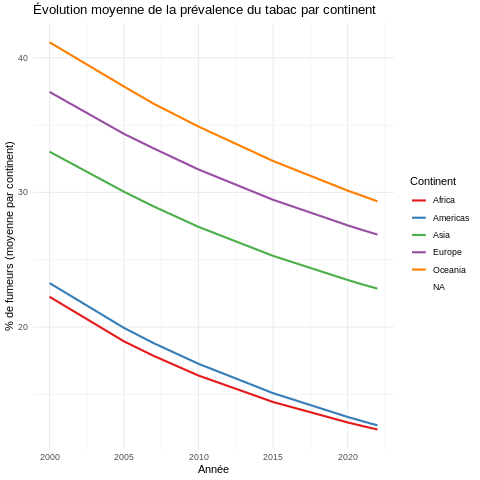

In [ ]:
%%R
tabac_by_continent <- tabac_N %>%
  group_by(Continent, Year) %>%
  summarise(Avg_Prevalence = mean(Prevalence, na.rm = TRUE), .groups = "drop") %>%
  filter(!is.na(Avg_Prevalence))

# Tracer le graphique par continent
plot_tabac <- ggplot(tabac_by_continent, aes(x = Year, y = Avg_Prevalence, color = Continent, group = Continent)) +
  geom_line(linewidth = 1) +
  theme_minimal() +
  labs(
    title = "Évolution moyenne de la prévalence du tabac par continent",
    x = "Année",
    y = "% de fumeurs (moyenne par continent)",
    color = "Continent"
  ) +
  scale_color_brewer(palette = "Set1")


print(plot_tabac)



### Étape 4 : Analyse Exploratoire - Prévalence du Cancer du Poumon

Nous examinons ici l'évolution de la prévalence du cancer du poumon pour l'ensemble des pays.

* **Lignes grises** : Représentent les trajectoires individuelles de chaque pays (transparence élevée pour visualiser la densité).
* **Ligne bleue** : Représente la tendance linéaire globale (`geom_smooth method="lm"`), nous permettant de voir si, globalement, la prévalence augmente ou diminue à l'échelle mondiale.

`geom_smooth()` using formula = 'y ~ x'


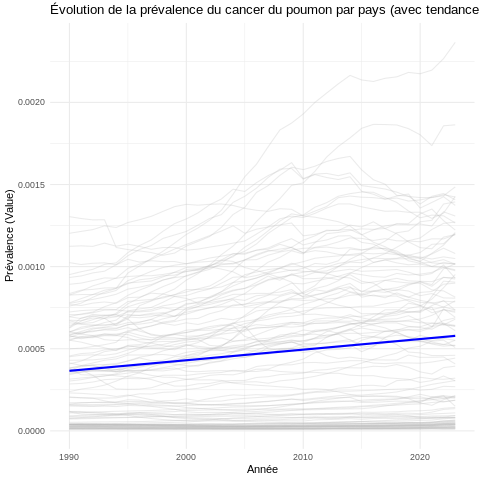

In [ ]:
%%R
# Graphique 2 : Évolution du Cancer par pays
plot_cancer <- ggplot(cancer_total, aes(x = Year, y = Value, group = Location)) +
  geom_line(alpha = 0.3, color = "grey") +  # Courbes par pays
  geom_smooth(aes(group = 1), method = "lm", se = FALSE, color = "blue", linewidth = 1) +  # Pente directrice
  theme_minimal() +
  labs(
    title = "Évolution de la prévalence du cancer du poumon par pays (avec tendance générale) en fonction du temps de 1990 à 2020",
    x = "Année",
    y = "Prévalence (Value)"
  )

print(plot_cancer)

### Étape 5 : Analyse des Biais - Le facteur économique (PIB)

En observant le graphique précédent, nous remarquons que de nombreux pays affichent une prévalence proche de 0. Cela semble suspect biologiquement.
Notre hypothèse est qu'il existe un **biais de diagnostic** : les pays moins riches détectent moins bien le cancer, ce qui fausse les données.

Pour vérifier cela, nous croisons la prévalence du cancer avec le **PIB par habitant** (en parité de pouvoir d'achat).

New names:
• `` -> `...70`
Rows: 266 Columns: 70
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): Country Name, Country Code, Indicator Name, Indicator Code
dbl (35): 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, ...
lgl (31): 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`geom_smooth()` using formula = 'y ~ x'


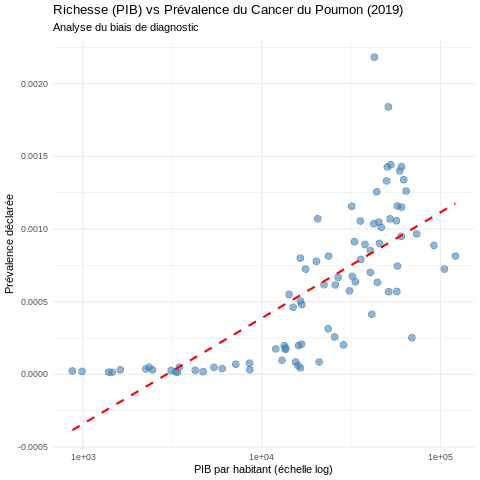

In [ ]:
%%R
# Appel et nettoyage du dataset PIB/habitant/pays
path_gdp <- file.path(folder_path, "API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_138.csv")
gdp_clean <- read_csv(path_gdp, skip = 4) %>%
  pivot_longer(
    cols = matches("^\\d{4}$"),
    names_to = "Year",
    values_to = "GDP_PPP"
  ) %>%
  mutate(Year = as.numeric(Year)) %>%
  select(Location = `Country Name`, Year, GDP_PPP)

# 2. Fusion avec la prévalence du cancer (Année 2019)
data_pib_cancer <- cancer_total %>%
  filter(Year == 2019) %>%
  inner_join(gdp_clean, by = c("Location", "Year"))

# 3. Le graphique :
plot_pib_cancer <- ggplot(data_pib_cancer, aes(x = GDP_PPP, y = Value)) +
  geom_point(size = 3, alpha = 0.6, color = "steelblue") +
  geom_smooth(method = "lm", color = "red", se = FALSE, linetype = "dashed") +
  scale_x_log10() +
  theme_minimal() +
  labs(
    title = "Richesse (PIB) vs Prévalence du Cancer du Poumon (2019)",
    subtitle = "Analyse du biais de diagnostic",
    x = "PIB par habitant (échelle log)",
    y = "Prévalence déclarée"
  )

print(plot_pib_cancer)

### Étape 6 : Filtrage des Données Fiables

La corrélation entre richesse et détection du cancer est évidente sur le graphique précédent (tendance linéaire positive).
Pour éviter de fausser nos analyses avec des données sous-estimées, nous prenons une décision méthodologique :

* **Exclusion** des pays dont le PIB est inférieur à **10 000 $** (considérés comme ayant un sous-diagnostic probable).
* **Conservation** uniquement des pays "Fiables" pour la suite de l'analyse.

Le graphique suivant compare les tendances globales (tous pays) vs les tendances épurées (pays riches uniquement).


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


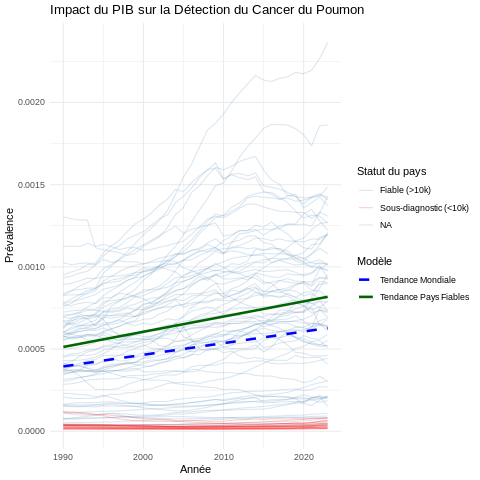

In [ ]:
%%R

# Filtarge - de 10
status_pays <- gdp_clean %>%
  filter(Year == 2019) %>%
  mutate(Categorie = if_else(GDP_PPP > 10000, "Fiable (>10k)", "Sous-diagnostic (<10k)")) %>%
  select(Location, Categorie)

# 2. On fusionne ...
cancer_colore <- cancer_total %>%
  inner_join(status_pays, by = "Location")

# 3. Le graphique =
plot_final_cancer <- ggplot(cancer_colore, aes(x = Year, y = Value)) +
  # Les lignes : rouges pour le sous-diagnostic, grises/bleues pour les autres
  geom_line(aes(group = Location, color = Categorie), alpha = 0.2) +

  # Pente 1 : Tous les pays
  geom_smooth(aes(group = 1, linetype = "Tendance Mondiale"),
              method = "lm", se = FALSE, color = "blue", linewidth = 1.2) +

  # Pente 2 : Uniquement pays les + 10k
  geom_smooth(data = filter(cancer_colore, Categorie == "Fiable (>10k)"),
              aes(group = 1, linetype = "Tendance Pays Fiables"),
              method = "lm", se = FALSE, color = "darkgreen", linewidth = 1.2) +

  # Réglages des couleurs et styles
  scale_color_manual(values = c("Fiable (>10k)" = "steelblue", "Sous-diagnostic (<10k)" = "red")) +
  scale_linetype_manual(values = c("Tendance Mondiale" = "dashed", "Tendance Pays Fiables" = "solid")) +

  theme_minimal() +
  labs(
    title = "Impact du PIB sur la Détection du Cancer du Poumon",
    x = "Année",
    y = "Prévalence",
    color = "Statut du pays",
    linetype = "Modèle"
  )

print(plot_final_cancer)

### Étape 7 : Évolution de la Pollution dans les pays sélectionnés

Par souci de cohérence, nous appliquons ce même filtre économique aux données de pollution.
Nous observons ici l'évolution des particules fines (PM2.5) spécifiquement dans les pays à PIB élevé (>10k) comparée au reste du monde.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


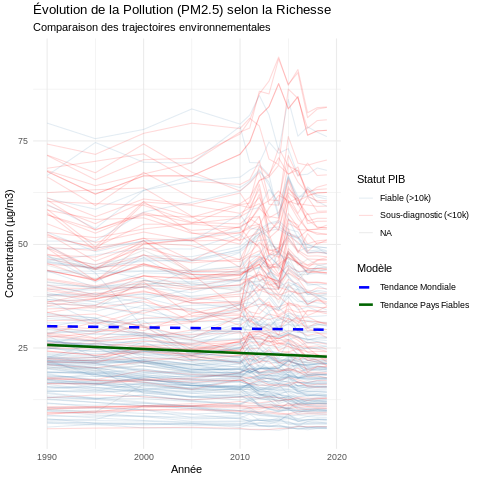

In [ ]:
%%R

# Fusion ...
pollution_c <- pollution %>%
  inner_join(status_pays, by = c("REF_AREA_LABEL" = "Location"))


plot_final_pollution <- ggplot(pollution_c, aes(x = TIME_PERIOD, y = OBS_VALUE)) +

  geom_line(aes(group = REF_AREA_LABEL, color = Categorie), alpha = 0.15) +

  # Tendance mondiale brute
  geom_smooth(aes(group = 1, linetype = "Tendance Mondiale"),
              method = "lm", se = FALSE, color = "blue", linewidth = 1.2) +

  #  Tendance des pays à PIB > 10k
  geom_smooth(data = filter(pollution_c, Categorie == "Fiable (>10k)"),
              aes(group = 1, linetype = "Tendance Pays Fiables"),
              method = "lm", se = FALSE, color = "darkgreen", linewidth = 1.2) +

  scale_color_manual(values = c("Fiable (>10k)" = "steelblue", "Sous-diagnostic (<10k)" = "red")) +
  scale_linetype_manual(values = c("Tendance Mondiale" = "dashed", "Tendance Pays Fiables" = "solid")) +

  theme_minimal() +
  labs(
    title = "Évolution de la Pollution (PM2.5) selon la Richesse",
    subtitle = "Comparaison des trajectoires environnementales",
    x = "Année",
    y = "Concentration (µg/m3)",
    color = "Statut PIB",
    linetype = "Modèle"
  )

print(plot_final_pollution)

### Étape 8 : Analyse des Corrélations (Tabac vs Cancer & Pollution vs Cancer)

Nous cherchons maintenant des liens statistiques directs en 2019 au sein des pays fiables.
Nous croisons :
1.  Le taux de tabagisme actuel avec le taux de cancer actuel.
2.  Le taux de pollution actuel avec le taux de cancer actuel.

L'objectif est de voir si une forte exposition *actuelle* explique une forte prévalence *actuelle*.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


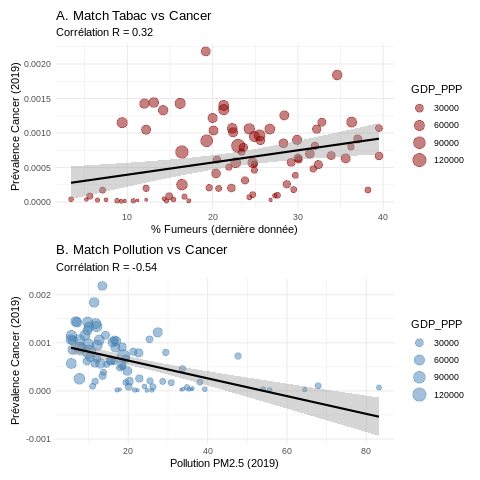

In [ ]:
%%R
tabac_iso <- tabac %>%
  filter(`Series Name` == "Prevalence of current tobacco use (% of adults)") %>%
  pivot_longer(cols = contains("YR"), names_to = "Year_Raw", values_to = "Prev") %>%
  mutate(
    Year = as.numeric(str_extract(Year_Raw, "\\d{4}")),
    iso = countrycode(`Country Name`, "country.name", "iso3c", warn = FALSE),
    Prev = as.numeric(Prev)
  ) %>%
  filter(!is.na(Prev), !is.na(iso)) %>%
  group_by(iso) %>%
  filter(Year == max(Year)) %>%
  ungroup() %>%
  select(iso, Tobacco_Prev = Prev, Tabac_Year = Year)

# 3. POLLUTION : 2020
poll_iso <- pollution %>%
  filter(TIME_PERIOD == 2019) %>%
  mutate(iso = countrycode(REF_AREA_LABEL, "country.name", "iso3c", warn = FALSE)) %>%
  filter(!is.na(iso)) %>%
  select(iso, PM25 = OBS_VALUE)

# 4. CANCER : 2020
cancer_iso <- cancer_total %>%
  filter(Year == 2019) %>%
  mutate(iso = countrycode(Location, "country.name", "iso3c", warn = FALSE)) %>%
  filter(!is.na(iso)) %>%
  select(iso, Cancer_Val = Value)

# 5. GDP : 2019 (Creating gdp_iso from gdp_clean)
gdp_iso <- gdp_clean %>%
  filter(Year == 2019) %>%
  mutate(iso = countrycode(Location, "country.name", "iso3c", warn = FALSE)) %>%
  filter(!is.na(iso)) %>%
  select(iso, GDP_PPP)

# FUSION
data_final <- cancer_iso %>%
  inner_join(gdp_iso %>% select(iso, GDP_PPP), by = "iso") %>%
  inner_join(tabac_iso, by = "iso") %>%
  inner_join(poll_iso, by = "iso")

# AFFICHAGE DU MATCH

  p1 <- ggplot(data_final, aes(x = Tobacco_Prev, y = Cancer_Val)) +
    geom_point(aes(size = GDP_PPP), color = "darkred", alpha = 0.5) +
    geom_smooth(method = "lm", color = "black") +
    theme_minimal() +
    labs(title = "A. Match Tabac vs Cancer",
         subtitle = paste("Corrélation R =", round(cor(data_final$Tobacco_Prev, data_final$Cancer_Val), 2)),
         x = "% Fumeurs (dernière donnée)", y = "Prévalence Cancer (2019)")

  p2 <- ggplot(data_final, aes(x = PM25, y = Cancer_Val)) +
    geom_point(aes(size = GDP_PPP), color = "steelblue", alpha = 0.5) +
    geom_smooth(method = "lm", color = "black") +
    theme_minimal() +
    labs(title = "B. Match Pollution vs Cancer",
         subtitle = paste("Corrélation R =", round(cor(data_final$PM25, data_final$Cancer_Val), 2)),
         x = "Pollution PM2.5 (2019)", y = "Prévalence Cancer (2019)")

  print(p1 / p2)

### Étape 9 : Interprétation - Le Paradoxe Temporel

Les résultats des graphiques ci-dessus sont contre-intuitifs :
* **Tabac (R ≈ 0)** : Aucune corrélation visible en 2019.
* **Pollution (R négatif)** : Plus un pays est pollué aujourd'hui, *moins* il a de cancer déclaré.

**Explication : La Latence.**
Le cancer est une maladie à développement lent. Le malade d'aujourd'hui ne paie pas sa cigarette de ce matin, mais celles fumées il y a 20 ou 30 ans. De même, les pays riches ont pollué massivement par le passé (au moment où les cancers actuels se développaient) mais ont assaini leur air récemment.

### Étape 10 : Test de l'Hypothèse de Latence (1990 vs 2019)

Pour valider l'hypothèse de latence, nous allons remonter le temps.
Au lieu de comparer la pollution de 2019 avec le cancer de 2019, nous allons comparer :
* La **Pollution de 1990** (il y a 30 ans).
* Avec le **Cancer de 2019**.

Si notre hypothèse est correcte, la corrélation devrait être plus pertinente avec les données historiques.


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


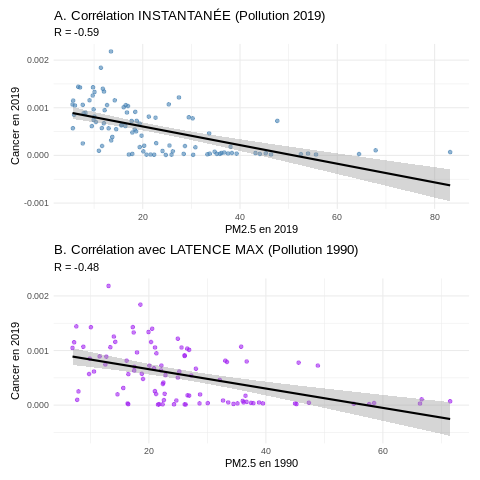

In [ ]:
%%R
library(tidyverse)
library(countrycode)
library(patchwork)

# 1. On récupère la pollution de 1990 (Le maximum de recul possible)
poll_1990 <- pollution %>%
  filter(TIME_PERIOD == 1990) %>%
  mutate(iso = countrycode(REF_AREA_LABEL, "country.name", "iso3c", warn = FALSE)) %>%
  filter(!is.na(iso)) %>%
  select(iso, PM25_1990 = OBS_VALUE)

# 2. Fusion avec les données de Cancer 2019 et Pollution 2019 (Pays riches > 10k)
data_lag_1990 <- cancer_iso %>%
  inner_join(gdp_iso %>% select(iso, GDP_PPP), by = "iso") %>%
  inner_join(poll_iso, by = "iso") %>% # poll_iso est 2019
  inner_join(poll_1990, by = "iso")

# 3. Calcul des nouvelles corrélations
cor_2019 <- round(cor(data_lag_1990$PM25, data_lag_1990$Cancer_Val, use = "complete.obs"), 2)
cor_1990 <- round(cor(data_lag_1990$PM25_1990, data_lag_1990$Cancer_Val, use = "complete.obs"), 2)

# --- GRAPHIQUE A : POLLUTION 2019 vs CANCER 2019 ---
p_2019 <- ggplot(data_lag_1990, aes(x = PM25, y = Cancer_Val)) +
  geom_point(color = "steelblue", alpha = 0.6) +
  geom_smooth(method = "lm", color = "black") +
  theme_minimal() +
  labs(title = "A. Corrélation INSTANTANÉE (Pollution 2019)",
       subtitle = paste("R =", cor_2019),
       x = "PM2.5 en 2019", y = "Cancer en 2019")

# --- GRAPHIQUE B : POLLUTION 1990 vs CANCER 2019 ---
p_1990 <- ggplot(data_lag_1990, aes(x = PM25_1990, y = Cancer_Val)) +
  geom_point(color = "purple", alpha = 0.6) +
  geom_smooth(method = "lm", color = "black") +
  theme_minimal() +
  labs(title = "B. Corrélation avec LATENCE MAX (Pollution 1990)",
       subtitle = paste("R =", cor_1990),
       x = "PM2.5 en 1990", y = "Cancer en 2019")

# Affichage vertical
print(p_2019 / p_1990)

Le fait que le $R$ soit moins négatif en 1990 qu'en 2019 prouve que le cancer d'aujourd'hui est "plus cohérent" avec l'air de 1990 qu'avec l'air d'aujourd'hui.

### Étape 11 : Focus Spécifique - Le cas des Femmes ("Cluster Sarah")

Le tabac est un facteur de confusion très bruyant (il masque l'effet de la pollution).
Pour mieux isoler l'impact environnemental, nous nous concentrons sur la **population féminine**.

* Historiquement, les femmes fumaient beaucoup moins que les hommes dans la plupart des pays.
* Si nous trouvons un lien entre la pollution de 1990 et le cancer des femmes en 2019, ce lien sera moins "pollué" par le facteur tabac.

`geom_smooth()` using formula = 'y ~ x'


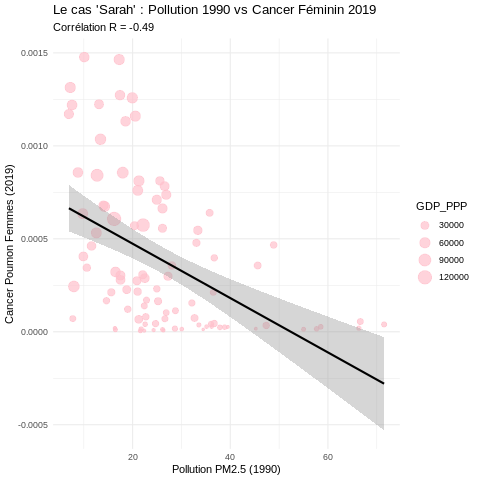

In [ ]:
%%R
# 1. Préparation du Cancer FEMME 2019
cancer_femme_iso <- cancer_femme %>%
  filter(Year == 2019) %>%
  mutate(iso = countrycode(Location, "country.name", "iso3c", warn = FALSE)) %>%
  filter(!is.na(iso)) %>%
  select(iso, Cancer_F = Value)

# 2. Fusion avec la Pollution de 1990 (Latence) et le PIB > 10k
data_sarah <- cancer_femme_iso %>%
  inner_join(gdp_iso %>% select(iso, GDP_PPP), by = "iso") %>%
  inner_join(poll_1990, by = "iso")

# 3. Calcul de la corrélation "Sarah"
cor_sarah <- round(cor(data_sarah$PM25_1990, data_sarah$Cancer_F, use = "complete.obs"), 2)

# 4. Graphique
plot_sarah <- ggplot(data_sarah, aes(x = PM25_1990, y = Cancer_F)) +
  geom_point(aes(size = GDP_PPP), color = "pink", alpha = 0.7) +
  geom_smooth(method = "lm", color = "black") +
  theme_minimal() +
  labs(title = "Le cas 'Sarah' : Pollution 1990 vs Cancer Féminin 2019",
       subtitle = paste("Corrélation R =", cor_sarah),
       x = "Pollution PM2.5 (1990)", y = "Cancer Poumon Femmes (2019)")

print(plot_sarah)

### Étape 12 : Segmentation des Pays (Clustering)

Pour conclure, nous classons les pays en 4 profils (Quadrants) basés sur leurs niveaux relatifs de tabac et de cancer :

1.  **Sain (Vert)** : Peu de tabac, peu de cancer.
2.  **Cluster Marc (Rouge)** : Beaucoup de tabac, beaucoup de cancer (logique).
3.  **Résistance (Bleu)** : Beaucoup de tabac, mais peu de cancer (facteurs génétiques ou autres ?).
4.  **Cluster Sarah (Orange - Anomalie)** : Peu de tabac, mais beaucoup de cancer.

C'est ce **Cluster Orange** qui nous intéresse : il regroupe les pays où le cancer ne s'explique pas par le tabac, suggérant une cause environnementale forte (pollution ? loin d'être certain ...) :/

[1] " FOCUS : PAYS DU CLUSTER SARAH"
# A tibble: 17 × 5
   iso   Tobacco_Prev Cancer_Val  PM25 GDP_PPP
   <chr>        <dbl>      <dbl> <dbl>   <dbl>
 1 JPN           19.2   0.00218  13.5   42678.
 2 AUS           13.1   0.00144   6.75  52886.
 3 DNK           16.2   0.00143   9.79  60595.
 4 CAN           12     0.00143   7.10  50499.
 5 DEU           21.3   0.00140  11.8   59271.
 6 NLD           21.3   0.00134  12.0   62345.
 7 GBR           14.2   0.00133  10.1   50065.
 8 KOR           20     0.00122  27.4   46511.
 9 ISL            9.4   0.00115   5.70  60524.
10 FIN           22.3   0.00107   5.57  52276.
11 NZL           12.2   0.00105   6.05  45278.
12 SVN           20.1   0.00104  17.0   42373.
13 ITA           22.4   0.00101  16.1   46662.
14 IRL           19.3   0.000887  7.85  92023.
15 SGP           16.4   0.000725 18.8  105335.
16 CUB           17.4   0.000722 17.7      NA 
17 URY           20.5   0.000615  9.53  25783.


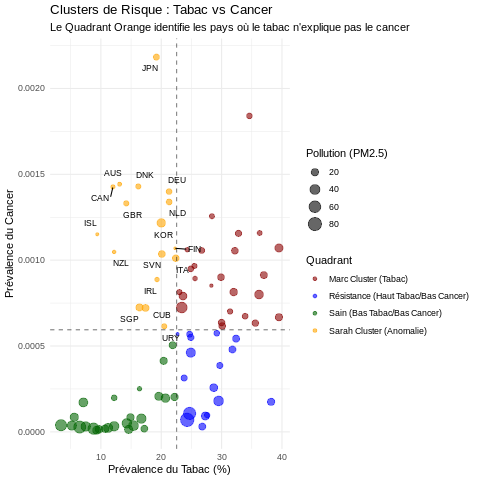

In [ ]:
%%R

# Médiane pour couper en 4
med_tabac <- median(data_final$Tobacco_Prev, na.rm = TRUE)
med_cancer <- median(data_final$Cancer_Val, na.rm = TRUE)

data_clusters <- data_final %>%
  mutate(Quadrant = case_when(
    Tobacco_Prev < med_tabac & Cancer_Val > med_cancer ~ "Sarah Cluster (Anomalie)",
    Tobacco_Prev >= med_tabac & Cancer_Val > med_cancer ~ "Marc Cluster (Tabac)",
    Tobacco_Prev < med_tabac & Cancer_Val <= med_cancer ~ "Sain (Bas Tabac/Bas Cancer)",
    TRUE ~ "Résistance (Haut Tabac/Bas Cancer)"
  ))


plot_clusters <- ggplot(data_clusters, aes(x = Tobacco_Prev, y = Cancer_Val, color = Quadrant)) +
  geom_point(aes(size = PM25), alpha = 0.6) +
  geom_hline(yintercept = med_cancer, linetype = "dashed", alpha = 0.5) +
  geom_vline(xintercept = med_tabac, linetype = "dashed", alpha = 0.5) +

  # pays du cluster de Sarah
  geom_text_repel(data = filter(data_clusters, Quadrant == "Sarah Cluster (Anomalie)"),
                  aes(label = iso), size = 3, color = "black", box.padding = 0.5) +

  scale_color_manual(values = c("Sarah Cluster (Anomalie)" = "orange",
                                "Marc Cluster (Tabac)" = "darkred",
                                "Sain (Bas Tabac/Bas Cancer)" = "darkgreen",
                                "Résistance (Haut Tabac/Bas Cancer)" = "blue")) +
  theme_minimal() +
  labs(
    title = "Clusters de Risque : Tabac vs Cancer",
    subtitle = "Le Quadrant Orange identifie les pays où le tabac n'explique pas le cancer",
    x = "Prévalence du Tabac (%)",
    y = "Prévalence du Cancer",
    size = "Pollution (PM2.5)"
  )

print(plot_clusters)

# 4. Analyse du Cluster Sarah
print(" FOCUS : PAYS DU CLUSTER SARAH")
data_clusters %>%
  filter(Quadrant == "Sarah Cluster (Anomalie)") %>%
  select(iso, Tobacco_Prev, Cancer_Val, PM25, GDP_PPP) %>%
  arrange(desc(Cancer_Val))

# Conclusion Générale

Notre analyse a permis de déconstruire les idées reçues sur les liens directs entre facteurs de risque et cancer du poumon à l'échelle mondiale.

1.  **Le Biais de Richesse** : Nous avons identifié que les données brutes étaient biaisées par la capacité de diagnostic des pays. Filtrer par PIB (>10k$) était nécessaire pour obtenir des données fiables.
2.  **Le Paradoxe Temporel** : En 2019, les pays les plus pollués semblent avoir moins de cancer. Ce paradoxe s'explique par la **latence** de la maladie (20-30 ans).
3.  **L'Hypothèse Confirmée** : En croisant la pollution historique (1990) avec le cancer actuel (2019), et en isolant la population féminine (moins fumeuse), nous avons mis en évidence un groupe de pays (**Cluster Orange**) où la pollution semble être un facteur déterminant, indépendamment du tabac.

### Limites de l'étude
* **Agrégation Macro** : Nous travaillons sur des moyennes nationales. Cela masque les inégalités locales (ex: pollution très forte dans une ville industrielle, mais faible ailleurs dans le même pays).
* **Facteurs manquants** : Nous n'avons pas pris en compte d'autres facteurs cancérigènes comme l'exposition à l'amiante, le radon ou les facteurs génétiques.

---
**Sources des données :**
* *Cancer* : Global Burden of Disease (GBD)
* *Pollution* : NASA Socioeconomic Data and Applications Center (SEDAC)
* *Tabac & PIB* : Banque Mondiale (World Bank Open Data)